# Propagating a focused, linearly polarized Gaussian beam

**Use case:** determine how a 532 nm Gaussian beam spreads over 30 µm and whether
its longitudinal electric component can be neglected. We start from a measured
or specified waist-plane pair $(E_x,E_y)$, complete the missing $E_z$ through
$\mathbf k\cdot\mathbf E=0$, and propagate the resulting Maxwell spectrum.

The field is $\Re[\mathbf E(\mathbf r)e^{-i\omega t}]$, with peak input
$E_x=1$ V/m. Coordinates are in µm. Maps of $|\mathbf E|^2$ measure electric
amplitude squared; transported power is calculated separately from
$\langle\mathbf S\rangle=\Re(\mathbf E\times\mathbf H_{SI}^*)/2$.

**Questions:** Where is the waist? Does the numerical beam follow the paraxial
width prediction? How large is $E_z$, and is the normal power conserved?

In [1]:
# Locate this checkout and initialize inline figures.

from pathlib import Path
import sys

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()
)
sys.path.insert(0, str(root))
from IPython import get_ipython

get_ipython().run_line_magic("matplotlib", "inline")
import numpy as np
import matplotlib.pyplot as plt
from examples.notebook_tools import style, show, scalar_map, polarization_map, fwhm

style()

## 1. Define the waist and complete the vector field

$$E_x(x,y,0)=E_0e^{-(x^2+y^2)/w_0^2},\quad E_y=0,\qquad
\widetilde E_z=-\frac{k_x\widetilde E_x+k_y\widetilde E_y}{k_z}.$$
`TransverseElectricField` means that $E_z$ is unspecified, not zero.
We use $w_0=1.2$ µm, a 25.6 µm numerical period, and 100 nm pixels.
FFT propagation assumes periodic boundary conditions; the beam must remain
well inside the window.

In [2]:
from vecdiff import (
    CartesianGrid,
    PlaneDomain,
    TransverseElectricField,
    propagate,
    spectrum_of,
)
from vecdiff.observables.electromagnetism import poynting

wavelength, waist = 0.532, 1.2
grid = CartesianGrid.from_spacing(0.1, 256)
X, Y = grid.xy

input_field = TransverseElectricField(
    np.exp(-(X * X + Y * Y) / waist**2), 0 * X, grid, PlaneDomain(), wavelength
)

field = input_field.complete()
zR = np.pi * waist**2 / wavelength
print(f"Rayleigh range (paraxial reference): {zR:.3f} µm")

Rayleigh range (paraxial reference): 8.504 µm


**Waist observation plane:** x–y at z = 0; both axes are transverse.

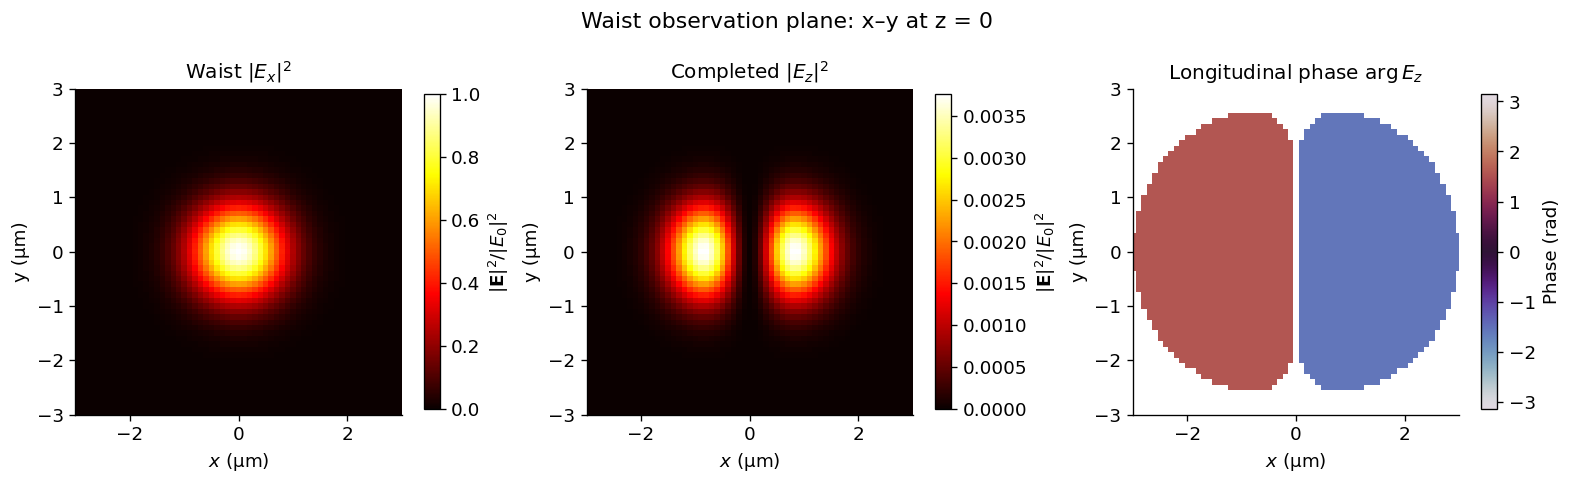

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), layout="constrained")
fig.suptitle("Waist observation plane: x–y at z = 0")

for ax, values, title in zip(
    axes,
    [abs(field.Ex) ** 2, abs(field.Ez) ** 2, np.angle(field.Ez)],
    [r"Waist $|E_x|^2$", r"Completed $|E_z|^2$", r"Longitudinal phase $\arg E_z$"],
):
    if ax is axes[2]:
        values = np.where(
            abs(field.Ez) ** 2 > 1e-4 * np.max(abs(field.Ez) ** 2), values, np.nan
        )
        scalar_map(
            fig,
            ax,
            values,
            grid.x,
            grid.y,
            title,
            label="Phase (rad)",
            ylabel="y (µm)",
            cmap="twilight",
            vmin=-np.pi,
            vmax=np.pi,
        )
    else:
        scalar_map(fig, ax, values, grid.x, grid.y, title, ylabel="y (µm)")

    ax.set(xlim=(-3, 3), ylim=(-3, 3), aspect="equal")

show(fig, "01_waist_vector")

## 2. Propagate in the meridional x–z plane at y = 0

Each spatial frequency acquires $e^{ik_z z}$, with the decaying branch for
evanescent waves. We retain the complex field. The following x–z maps use
241 axial planes and show both the total electric norm and the longitudinal
component on their stated, absolute input-amplitude scales.

In [4]:
# Propagate plane by plane; record meridional intensity, width, edge leakage, and flux.

zs = np.linspace(0, 30, 241)
meridional = []
longitudinal = []
widths = []
flux = []
edge = []
spectrum = spectrum_of(field)

for z in zs:
    propagated = propagate(field, float(z))
    e = propagated.components
    intensity = np.sum(abs(e) ** 2, axis=-1)

    # Store the meridional section and longitudinal contribution.
    meridional.append(intensity[len(grid.y) // 2])
    longitudinal.append(abs(propagated.Ez[len(grid.y) // 2]) ** 2)

    # Track width and periodic-window leakage separately from field flux.
    widths.append(2 * np.sqrt(np.sum(X * X * intensity) / intensity.sum()))
    edge.append(
        float(np.sum(intensity[:, [0, -1]]) + np.sum(intensity[[0, -1], :]))
        / intensity.sum()
    )
    # Parseval sum of modal flux avoids reconstructing H with a dense all-to-all sum.
    phase = np.exp(1j * spectrum.wavevectors[:, 2] * z)[:, None]
    flux.append(
        float(
            np.sum(
                poynting(
                    spectrum.amplitudes * phase, spectrum.magnetic_amplitudes * phase
                )[:, 2]
            )
            * grid.period_area
            * 1e-12
        )
    )

**Meridional plane:** x–z at y = 0. The dashed radius is a paraxial reference.

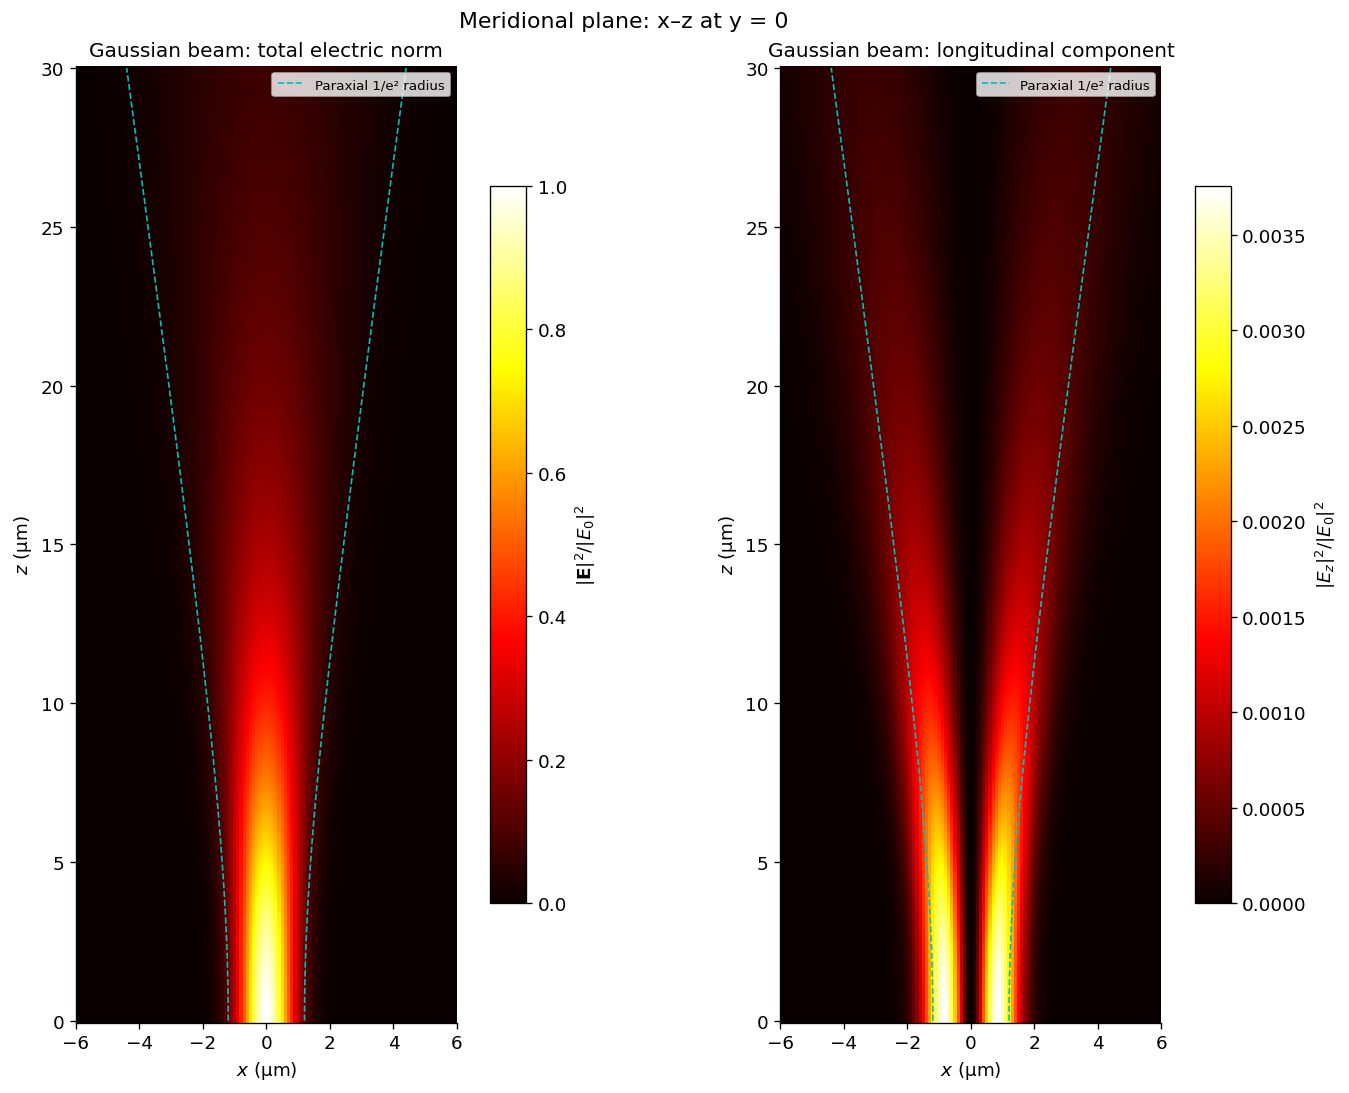

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 9), layout="constrained")
fig.suptitle("Meridional plane: x–z at y = 0")
scalar_map(
    fig,
    axes[0],
    np.array(meridional),
    grid.x,
    zs,
    "Gaussian beam: total electric norm",
    vmax=1,
)
scalar_map(
    fig,
    axes[1],
    np.array(longitudinal),
    grid.x,
    zs,
    "Gaussian beam: longitudinal component",
    label=r"$|E_z|^2/|E_0|^2$",
)

for ax in axes:
    paraxial = waist * np.sqrt(1 + (zs / zR) ** 2)
    ax.plot(paraxial, zs, "c--", lw=1, label="Paraxial 1/e² radius")
    ax.plot(-paraxial, zs, "c--", lw=1)
    ax.set(xlim=(-6, 6))
    ax.legend(fontsize=8, loc="upper right")

show(fig, "01_meridional_propagation")

## 3. Compare a measurable beam width and power

The second-moment radius is $w_x=2\sqrt{\langle x^2\rangle}$, evaluated here
from the total electric norm. For a paraxial Gaussian it is
$w(z)=w_0\sqrt{1+(z/z_R)^2}$. Differences can include vector/nonparaxial physics
and numerical truncation; the paraxial formula is an independent approximation,
not an exact high-NA standard. The power calculation uses modal Poynting flux,
not the electric norm.

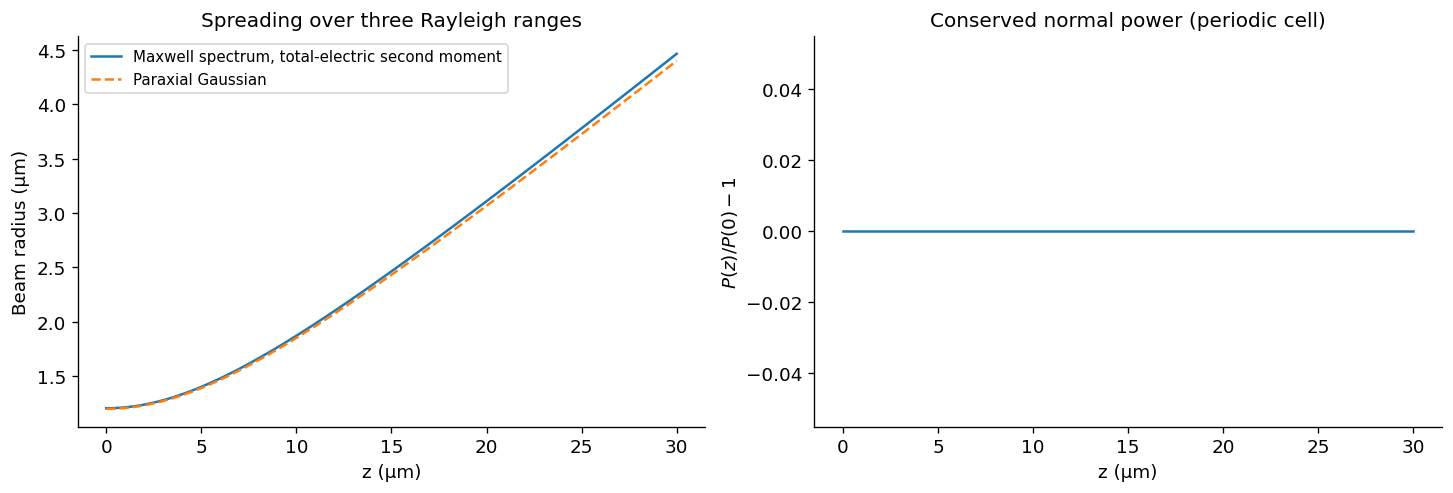

In [6]:
# Compare beam width and normal power, then inspect the output polarization.

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
axes[0].plot(zs, widths, label="Maxwell spectrum, total-electric second moment")
axes[0].plot(zs, waist * np.sqrt(1 + (zs / zR) ** 2), "--", label="Paraxial Gaussian")
axes[0].set(
    xlabel="z (µm)",
    ylabel="Beam radius (µm)",
    title="Spreading over three Rayleigh ranges",
)
axes[0].legend(fontsize=9)
axes[1].plot(zs, np.array(flux) / flux[0] - 1)
axes[1].set(
    xlabel="z (µm)",
    ylabel=r"$P(z)/P(0)-1$",
    title="Conserved normal power (periodic cell)",
)
show(fig, "01_width_power")

**Read the result:** Inspect the propagated output field and its polarization.

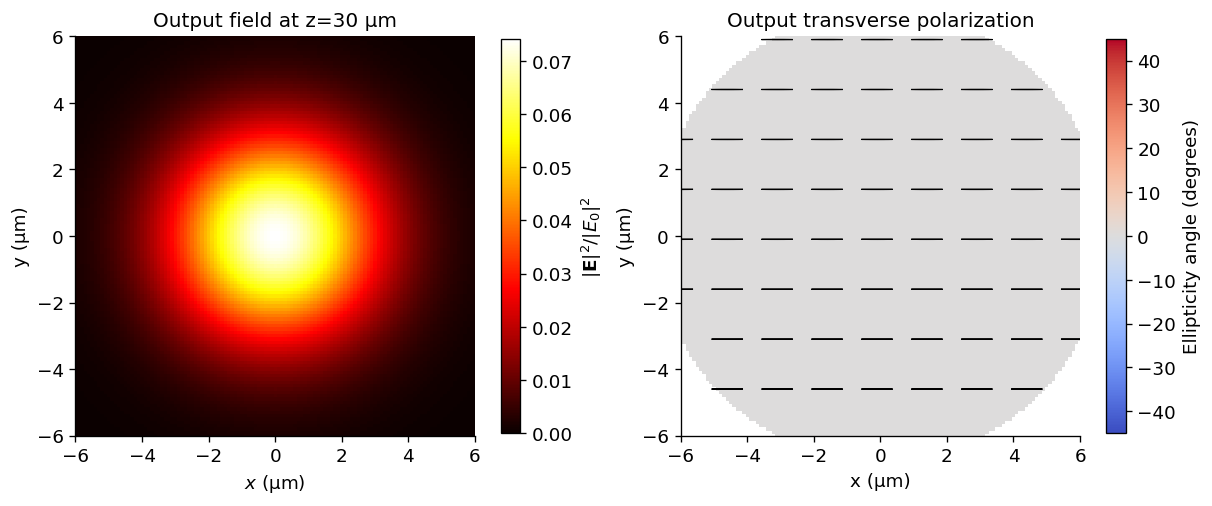

In [7]:
end = propagate(field, 30.0)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), layout="constrained")
scalar_map(
    fig,
    axes[0],
    end.norm2(),
    grid.x,
    grid.y,
    "Output field at z=30 µm",
    ylabel="y (µm)",
)
polarization_map(
    fig, axes[1], end.components, grid.x, grid.y, title="Output transverse polarization"
)

for ax in axes:
    ax.set(xlim=(-6, 6), ylim=(-6, 6), aspect="equal")

show(fig, "01_output_polarization")

**Read the result:** Read the numerical checks alongside the two field figures.

In [8]:
print(
    f"Input longitudinal electric-norm fraction: {np.sum(abs(field.Ez) ** 2) / np.sum(field.norm2()):.4%}"
)
print(f"Maximum relative power drift: {np.max(abs(np.array(flux) / flux[0] - 1)):.3g}")
print(f"Maximum fraction in outermost pixels: {max(edge):.3g}")

# Flux drift and window-edge leakage must remain below tolerance.
assert np.max(abs(np.array(flux) / flux[0] - 1)) < 1e-10
assert max(edge) < 1e-6

Input longitudinal electric-norm fraction: 0.5055%
Maximum relative power drift: 0
Maximum fraction in outermost pixels: 8.54e-08


## 4. Refine the physical window and pixel spacing independently

The two checks below compare complex fields in the central observation region.
They distinguish a finite FFT period from insufficient pixel resolution.
Changing the input Gaussian without also changing its wavelength or waist
preserves the same physical problem.

In [9]:
# Refine pixel spacing and physical window independently around the same beam.


def output_on_grid(dx, count):
    g = CartesianGrid.from_spacing(dx, count)
    xx, yy = g.xy
    f = TransverseElectricField(
        np.exp(-(xx * xx + yy * yy) / waist**2), 0 * xx, g, PlaneDomain(), wavelength
    ).complete()
    return propagate(f, 30.0)


# Hold wavelength and waist fixed while changing one grid property.
fine = output_on_grid(0.05, 512)
wide = output_on_grid(0.1, 512)
base = end.components
reference = fine.components[::2, ::2]
center = slice(48, 208)
resolution = np.linalg.norm((base - reference)[center, center]) / np.linalg.norm(
    reference[center, center]
)
reference = wide.components[128:384, 128:384]
window = np.linalg.norm((base - reference)[center, center]) / np.linalg.norm(
    reference[center, center]
)
print(f"100 → 50 nm pixels: complex-field change {resolution:.3g}")
print(f"25.6 → 51.2 µm period: complex-field change {window:.3g}")
assert resolution < 1e-6 and window < 1e-5

100 → 50 nm pixels: complex-field change 9.71e-14
25.6 → 51.2 µm period: complex-field change 1.93e-06


**Result to use:** this workflow takes a specified transverse waist field to a
complete propagated electric field, with a measured width, output polarization,
longitudinal fraction, power check and two independent sampling checks.
For a tighter focus, change `waist` and repeat these checks; the paraxial curve
will cease to be an adequate reference before the Maxwell representation does.

## 5. Continue propagation from an output field

A usable field can be propagated again. Two forward steps should equal their
combined distance. `propagate` works relative to the current plane, avoiding
a numerically growing evanescent re-reference to a distant global origin.
This does not make backward evanescent continuation well-conditioned.

In [10]:
# Check that two forward steps agree with one step of the same total distance.

first = propagate(field, 10.0)
continued = propagate(first, 20.0)

# Compare complex vector components, not only intensities.
composition_error = np.linalg.norm(
    continued.components - end.components
) / np.linalg.norm(end.components)
print(f"10 µm then 20 µm versus 30 µm directly: {composition_error:.3g}")
assert composition_error < 1e-10

10 µm then 20 µm versus 30 µm directly: 1.87e-14
